<div>
Olá, Iago!

Meu nome é Luiz. Fico feliz em revisar seu projeto. Ao longo do texto farei algumas observações sobre melhorias no código e também farei comentários sobre suas percepções sobre o assunto. Estarei aberto a feedbacks e discussões sobre o tema.

**Peço que mantenha e não altere os comentários que eu fizer por aqui para que possamos nos localizar posteriormente, ok?**

Mais uma coisa, vamos utilizar um código de cores para você entender o meu feedback no seu notebook. Funciona assim:

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

Sucesso. Tudo foi feito corretamente.
</div>

<div class="alert alert-block alert-warning">
<b>Comentário do revisor: </b> <a class="tocSkip"></a>

Alerta não crítico, mas que pode ser corrigido para melhoria geral no seu código/análise.
</div>

<div class="alert alert-block alert-danger">

<b>Comentário do revisor: </b> <a class="tocSkip"></a>
    
Erro que precisa ser arrumado, caso contrário seu projeto **não** será aceito.
</div>

Você pode interagir comigo através dessa célula:
<div class="alert alert-block alert-info">
<b>Resposta do Aluno.</b> <a class="tocSkip"></a>
</div>

<div class="alert alert-block alert-danger">
<b> Comentário geral do revisor v1</b> <a class="tocSkip"></a>
<s>
    
Obrigado por enviar o seu projeto e pelo esforço de chegar até aqui. O seu projeto possui alguns pontos bem interessantes, dos quais eu destaco:
    
- Código bem simples e estruturado 
- Comentários sucintos e bem objetivos
- Conclusões pertinentes em cada análise e etapa de avaliação
- Análises bem detalhadas em cada etapa do projeto
    
Entretanto, deixei alguns comentários em alguns trechos que precisam de ajuste. Peço que trabalhe nesses pontos para avançarmos.
    
Qualquer dúvida, pode contar comigo.   
    
    
**Até breve!**
</s>
</div>

## Etapa 1 – Importação e Exploração Inicial dos Dados

Nesta etapa, será importado o conjunto de dados `games.csv` e será feita uma análise inicial para entender sua estrutura, tipos de variáveis e presença de dados ausentes. Isso ajudará a definir os próximos passos da preparação e limpeza do conjunto de dados.

In [1]:
# Importando bibliotecas essenciais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Caminho do arquivo
file_path = '/datasets/games.csv'

# Carregando o dataset
df = pd.read_csv(file_path)

# Exibindo as 5 primeiras linhas
df.head()

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [2]:
# Informações gerais sobre colunas e tipos de dados
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [3]:
# Estatísticas descritivas para variáveis numéricas
df.describe()

,Year_of_Release,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score
count,16446.000000,16715.000000,16715.000000,16715.000000,16715.000000,8137.000000
mean,2006.484616,0.263377,0.145060,0.077617,0.047342,68.967679
std,5.877050,0.813604,0.503339,0.308853,0.186731,13.938165
min,1980.000000,0.000000,0.000000,0.000000,0.000000,13.000000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,60.000000
50%,2007.000000,0.080000,0.020000,0.000000,0.010000,71.000000
75%,2010.000000,0.240000,0.110000,0.040000,0.030000,79.000000
max,2016.000000,41.360000,28.960000,10.220000,10.570000,98.000000


In [4]:
# Verificando a quantidade de valores ausentes por coluna
df.isnull().sum()

Name                  2
Platform              0
Year_of_Release     269
Genre                 2
NA_sales              0
EU_sales              0
JP_sales              0
Other_sales           0
Critic_Score       8578
User_Score         6701
Rating             6766
dtype: int64

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

- Os dados foram carregados corretamente em célula separada
- O método `head()` foi utilizado para exibir uma amostra dos dados
- O método `info()` foi utilizado para estudo inicial dos dados
</div>

## Etapa 2 – Preparação dos Dados

Nesta etapa, serão realizados os seguintes procedimentos:

1. Renomear todas as colunas para letras minúsculas.
2. Corrigir os tipos de dados das colunas quando necessário.
3. Tratar valores ausentes, incluindo a substituição ou exclusão, e justificar a abordagem adotada.
4. Lidar com valores “TBD” na coluna `user_score`.
5. Calcular o total de vendas globais para cada jogo e adicionar esse valor em uma nova coluna.

In [5]:
# Renomeando todas as colunas para letras minúsculas
df.columns = df.columns.str.lower()

# Verificando o resultado
df.columns

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')

As colunas que precisam de conversão de tipo são:

- `year_of_release`: apesar de numérica, representa um ano. Será convertida para `Int64` (que aceita valores ausentes).
- `user_score`: atualmente como `object`, contém valores 'tbd' que precisam ser convertidos para `NaN`. Depois disso, converteremos a coluna para `float`.

In [6]:
# Substituindo 'tbd' por NaN na coluna user_score
df['user_score'] = df['user_score'].replace('tbd', np.nan)

# Convertendo user_score para float
df['user_score'] = df['user_score'].astype(float)

# Convertendo year_of_release para tipo inteiro que aceita nulos
df['year_of_release'] = df['year_of_release'].astype('Int64')

### Valores Ausentes

Colunas com valores ausentes e abordagem:

- `name`: Apenas 2 valores ausentes. Como o nome é essencial para a identificação do jogo, esses registros serão removidos.
- `genre`: 2 valores ausentes — também essenciais para a análise, serão removidos.
- `year_of_release`: 269 ausentes. Como o ano é importante para análises temporais, esses registros também serão removidos.
- `critic_score`, `user_score`, `rating`: os valores ausentes serão mantidos para evitar perda de dados relevantes. Eles serão tratados como ausentes durante a análise.

**Nota:** O valor "TBD" (to be determined) apareceu na coluna `user_score` e foi substituído por `NaN`.

#### Possíveis Razões para Valores Ausentes

A ausência de valores em algumas colunas pode ser explicada por diversos fatores:

- **`year_of_release`**: O ano de lançamento pode estar ausente para jogos ainda não lançados ou em fase de pré-lançamento no momento da coleta dos dados.
- **`critic_score` e `user_score`**: A falta de avaliação pode ocorrer porque:
  - O jogo é muito recente e ainda não foi amplamente avaliado.
  - O jogo recebeu pouca atenção da crítica ou dos usuários.
  - A plataforma de coleta não agregou notas para aquele título específico.
- **`rating` (classificação ESRB)**: Jogos independentes ou lançamentos internacionais podem não passar por avaliação do ESRB, ou a informação pode simplesmente não estar disponível em fontes abertas.

#### Tratamento de valores "TBD"

Na coluna `user_score`, encontra-se a sigla "TBD" (to be determined), que indica que a pontuação de usuários ainda não estava disponível no momento do levantamento dos dados. Esses valores foram convertidos para `NaN` para manter consistência nos tipos de dados e permitir o uso de operações estatísticas sem erro.

Optou-se por **manter os valores ausentes nas colunas `critic_score`, `user_score` e `rating`** para não descartar jogos relevantes que ainda não foram avaliados, e serão consideradas essas ausências durante a análise estatística e visualização.

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>
    
- Os tipos de dados foram convertidos corretamente.
- Os valores nulos foram estudados. Nesse caso, a melhor escolha é deixar os valores nulos como estão mesmo para evitar que a distribuição original dos dados seja distorcida.
</div>

In [7]:
# Removendo registros com valores ausentes em colunas críticas
df = df.dropna(subset=['name', 'genre', 'year_of_release'])

In [8]:
# Criando coluna de vendas globais
df['total_sales'] = df[['na_sales', 'eu_sales', 'jp_sales', 'other_sales']].sum(axis=1)

# Exibindo as 5 primeiras linhas com a nova coluna
df[['name', 'na_sales', 'eu_sales', 'jp_sales', 'other_sales', 'total_sales']].head()

,name,na_sales,eu_sales,jp_sales,other_sales,total_sales
0,Wii Sports,41.36,28.96,3.77,8.45,82.54
1,Super Mario Bros.,29.08,3.58,6.81,0.77,40.24
2,Mario Kart Wii,15.68,12.76,3.79,3.29,35.52
3,Wii Sports Resort,15.61,10.93,3.28,2.95,32.77
4,Pokemon Red/Pokemon Blue,11.27,8.89,10.22,1.00,31.38


<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>
    
A receita total foi calculada e um novo atributo foi criado (`total_sales`)
</div>

## Etapa 3 – Análise Exploratória dos Dados

Nesta etapa, serão investigados padrões temporais e de vendas, além de identificar as plataformas e gêneros mais relevantes. A ideia é compreender:

1. Quantidade de jogos lançados por ano.
2. Variação das vendas por plataforma ao longo do tempo.
3. Seleção do período ideal para análise (relevante para prever 2017).
4. Avaliação das plataformas mais lucrativas.
5. Análise de distribuição de vendas por plataforma.
6. Relação entre avaliações (usuários e críticos) e vendas.
7. Distribuição de vendas por gênero.

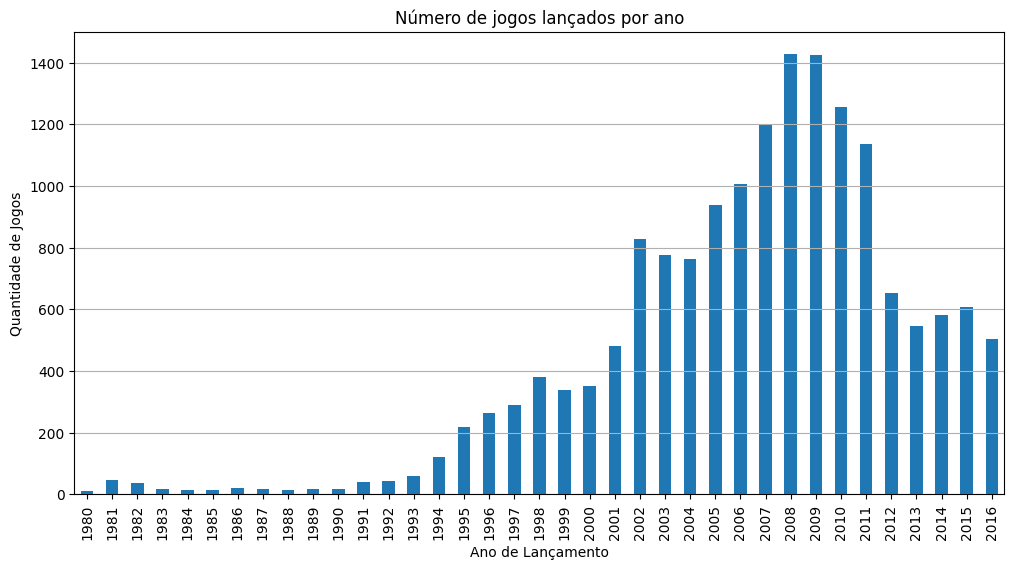

In [9]:
# Contagem de jogos por ano de lançamento
games_per_year = df['year_of_release'].value_counts().sort_index()

# Gráfico de barras
plt.figure(figsize=[12,6])
games_per_year.plot(kind='bar')
plt.title('Número de jogos lançados por ano')
plt.xlabel('Ano de Lançamento')
plt.ylabel('Quantidade de Jogos')
plt.grid(axis='y')
plt.show()

### Quantidade de Jogos Lançados por Ano

O gráfico acima mostra uma tendência clara de crescimento no número de lançamentos de jogos ao longo do tempo, especialmente a partir da década de 1990. Pode-se observar:

- Um crescimento expressivo entre os anos 2000 e 2009, com o **pico absoluto ocorrendo em 2008 e 2009**, onde mais de 1400 jogos foram lançados em cada ano.
- A partir de **2010**, há uma **queda gradual** na quantidade de jogos lançados.
- Os anos **2015 e 2016** apresentam números relativamente mais baixos. **No caso de 2016**, isso pode ser atribuído à incompletude dos dados (já que o dataset reflete uma coleta até dezembro de 2016 e pode não abranger o ano inteiro ou conter atrasos no registro dos lançamentos mais recentes).

Com isso, é possível concluir que há um **ciclo de maturação no mercado**, com crescimento, saturação e posterior declínio da produção em certos períodos. Esses dados serão fundamentais para definir o período ideal de análise na próxima seção.

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>
    
- A distribuição dos lançamentos ao longo dos anos foi analisada
- A conclusão foi apresentada
</div>

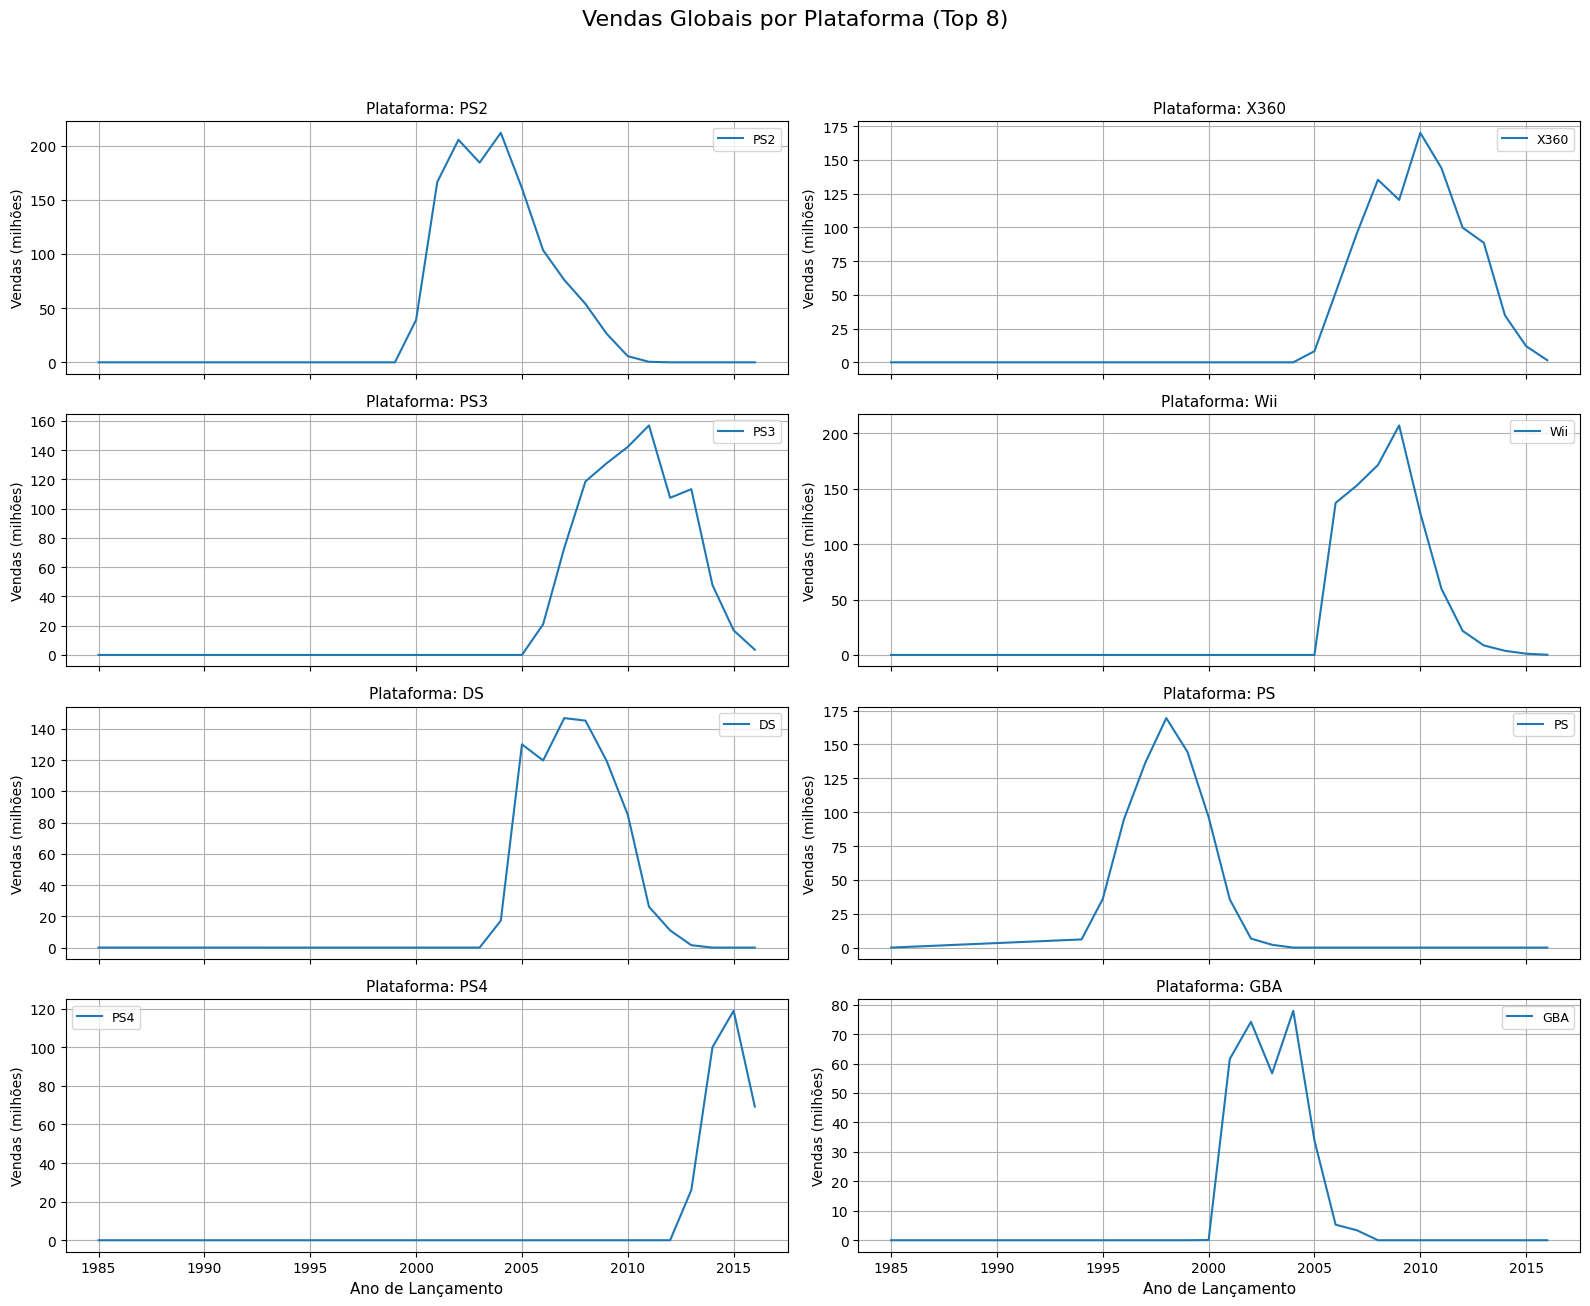

In [10]:
# Seleciona as 8 plataformas mais vendidas
top_platforms = df.groupby('platform')['total_sales'].sum().sort_values(ascending=False).head(8).index
filtered_df = df[df['platform'].isin(top_platforms)]

# Cria tabela dinâmica com vendas por ano
pivot = filtered_df.pivot_table(
    index='year_of_release',
    columns='platform',
    values='total_sales',
    aggfunc='sum'
).fillna(0)

# Subplots em grade 4x2
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=[16, 14], sharex=True)
axes = axes.flatten()

# Plota uma linha para cada plataforma em seu subplot
for i, platform in enumerate(top_platforms):
    axes[i].plot(pivot.index, pivot[platform], label=platform, color='tab:blue')
    axes[i].set_title(f'Plataforma: {platform}', fontsize=11)
    axes[i].set_ylabel('Vendas (milhões)', fontsize=10)
    axes[i].grid(True)
    axes[i].legend(fontsize=9)

# Eixo X apenas nos dois últimos subplots (para não poluir)
for ax in axes[-2:]:
    ax.set_xlabel('Ano de Lançamento', fontsize=11)

# Título principal da figura
fig.suptitle('Vendas Globais por Plataforma (Top 8)', fontsize=16)

# Ajuste de layout
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

### Vendas Globais por Plataforma (Top 8)

Os gráficos acima mostram a evolução das vendas ao longo dos anos para as 8 plataformas com maior volume acumulado. Separar cada plataforma em subplots individuais facilita a leitura e permite observar com clareza o **ciclo de vida típico de um console**:

- **PS2, Wii e DS** apresentam um padrão clássico de crescimento rápido seguido de queda acentuada após seu pico de vendas, indicando o declínio natural com a chegada de novas gerações.
- **PS3 e Xbox 360** dominaram boa parte da década de 2010, mantendo vendas estáveis por mais tempo.
- **PS4** ainda estava em ascensão em 2016, demonstrando forte presença no mercado e sendo um dos candidatos mais promissores para campanhas publicitárias em 2017.
- **GBA, PSP e PS** também seguiram o padrão de ascensão e queda, mas com menor representatividade nos últimos anos.

Esses dados confirmam que cada plataforma tende a ter um ciclo de relevância de cerca de **6 a 10 anos**, o que será útil para determinar a janela temporal mais eficiente para prever tendências em 2017.

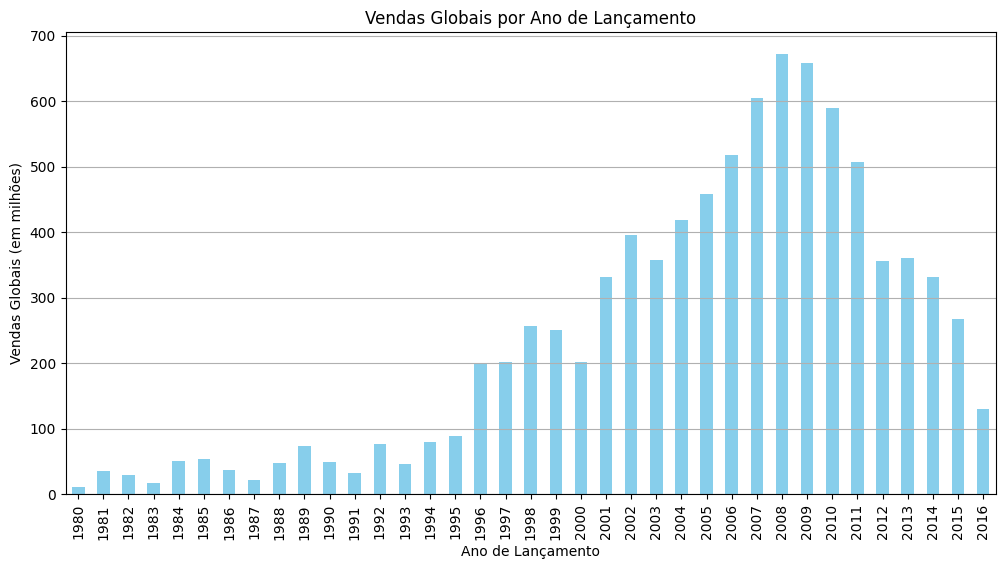

In [11]:
# Agrupando as vendas totais por ano
sales_by_year = df.groupby('year_of_release')['total_sales'].sum()

# Exibindo gráfico de barras
plt.figure(figsize=[12,6])
sales_by_year.plot(kind='bar', color='skyblue')
plt.title('Vendas Globais por Ano de Lançamento')
plt.xlabel('Ano de Lançamento')
plt.ylabel('Vendas Globais (em milhões)')
plt.grid(axis='y')
plt.show()

### Definindo o Período Ideal para Prever 2017

O gráfico acima mostra claramente a evolução das vendas globais de jogos ao longo do tempo. Com base na distribuição:

- As vendas cresceram de forma consistente até atingirem um **pico em 2008–2009**, ultrapassando 650 milhões de unidades.
- A partir de **2010**, iniciou-se uma **queda gradual nas vendas**.
- Embora os dados de 2015 ainda apresentem um volume considerável, o ano de **2016 mostra uma queda acentuada**, o que pode ser atribuído à **incompletude do dataset**, conforme alertado anteriormente.

Com isso em mente, **será considerado o período de 2011 a 2015** como janela de análise ideal para prever tendências de 2017. Essa janela representa os anos mais recentes com dados completos e confiáveis, refletindo o comportamento contemporâneo do mercado, inclusive para plataformas que ainda estão ativas.

O dataset será filtrado com base nessa janela para análises futuras.

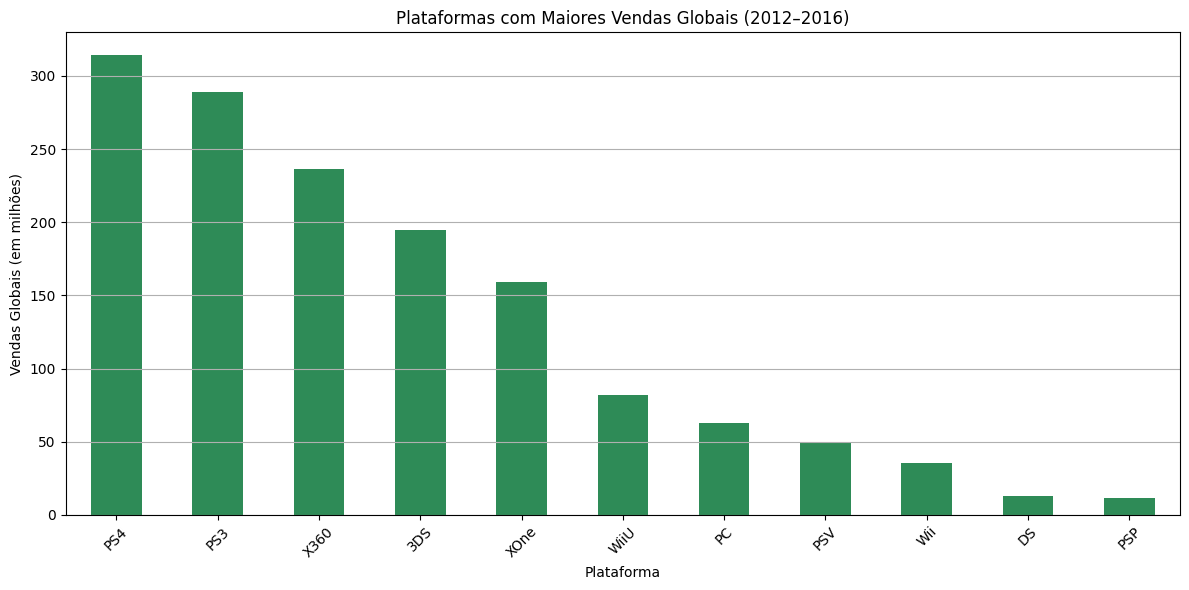

In [12]:
# Filtrando o dataframe para o período de interesse (2012–2016)
recent_df = df[df['year_of_release'].between(2012, 2016)]

# Agrupando as vendas totais por plataforma nesse período
recent_platform_sales = recent_df.groupby('platform')['total_sales'].sum().sort_values(ascending=False)

# Exibindo as plataformas com maiores vendas no período
plt.figure(figsize=[12, 6])
recent_platform_sales.plot(kind='bar', color='seagreen')
plt.title('Plataformas com Maiores Vendas Globais (2012–2016)')
plt.xlabel('Plataforma')
plt.ylabel('Vendas Globais (em milhões)')
plt.grid(axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Plataformas Mais Lucrativas (2012–2016)

O gráfico acima mostra as plataformas com maior volume de vendas globais no período de 2012 a 2016. A partir da visualização, podemos destacar:

- **PS4** lidera com folga, mesmo tendo sido lançado apenas em 2013, demonstrando um **crescimento extremamente acelerado** e uma rápida adoção pelo mercado.
- **PS3** ainda apresenta vendas significativas, sustentadas por sua base instalada e suporte contínuo de jogos durante o início da década.
- **X360** também mantém um volume considerável de vendas, apesar de sua transição para a nova geração.
- **Nintendo 3DS** mostra desempenho sólido, especialmente no nicho de jogos portáteis, consolidando-se como uma plataforma relevante.
- **XOne**, embora abaixo das líderes, ainda demonstra **crescimento consistente** desde seu lançamento em 2013.
- Outras plataformas como **WiiU, PC e PSV** contribuem de forma secundária, mas ainda têm participação relevante.
- Consoles como **Wii, DS e PSP** aparecem com vendas residuais, refletindo seu ciclo final de vida.

Com isso, as plataformas com **potencial lucrativo para 2017** são:

- **PS4** – Tendência clara de crescimento e ampla adoção desde 2013.
- **XOne** – Crescimento constante e alinhado à nova geração.
- **3DS** – Estabilidade no mercado de portáteis e boa aceitação.
- **PS3 / X360** – Apesar do declínio, ainda relevantes para retrocompatibilidade e catálogo extenso.

Essas plataformas serão o foco das análises subsequentes, incluindo distribuição por região, perfil de gêneros mais populares e comportamento das avaliações.

<div class="alert alert-block alert-danger">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>
<s>
    
Você precisa filtrar o dataframe pelo período relevante, através da coluna `year_of_release`. Dicas:
    
- Plote a distribuição dos dados para fazer esse filtro. Veja no gráfico histórico o período de maior concentração de dados
- Além disso, o período selecionado deve ser no máximo até 5 anos e até 2017 (ou seja, <=2017)
- O período selecionado não pode ser menor do que 3 anos                                          
- Sugestão: **filtre os dados a partir de `2012`**.
</s>
</div>

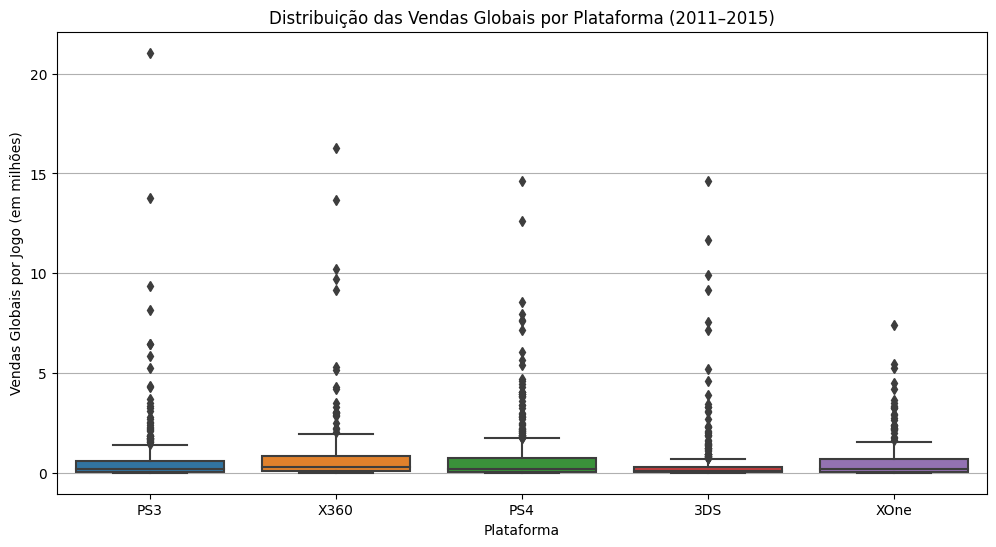

In [13]:
# Definindo as plataformas mais relevantes do período
relevant_platforms = ['PS4', 'XOne', '3DS', 'PS3', 'X360']

# Filtrando o dataframe para as plataformas selecionadas e período de 2012 a 2016
boxplot_df = df[
    (df['platform'].isin(relevant_platforms)) &
    (df['year_of_release'].between(2012, 2016))
]

# Criando o boxplot
plt.figure(figsize=[12, 6])
sns.boxplot(x='platform', y='total_sales', data=boxplot_df)
plt.title('Distribuição das Vendas Globais por Plataforma (2011–2015)')
plt.xlabel('Plataforma')
plt.ylabel('Vendas Globais por Jogo (em milhões)')
plt.grid(axis='y')
plt.show()

### Distribuição das Vendas Globais por Plataforma (2012–2016)

O boxplot acima mostra a distribuição das vendas por jogo (em milhões de unidades) para as cinco plataformas mais relevantes no período de 2012 a 2016.

#### Observações importantes:

- Todas as plataformas analisadas apresentam **outliers evidentes**, representando títulos de altíssimo desempenho (como franquias famosas ou sucessos de vendas).
- A maioria dos jogos vende menos de **1 milhão de cópias**, o que é indicado pelas **caixas compactas e medianas baixas**.
- **PS4** apresenta **a mediana mais alta**, sugerindo que seus títulos mantêm desempenho consistente e promissor no período analisado.
- **XOne** segue com uma mediana próxima da do PS4, reforçando seu crescimento como plataforma relevante.
- **PS3** e **X360**, embora tenham apresentado alguns dos maiores outliers, mostram uma **queda significativa na mediana**, o que indica declínio natural com o fim de seu ciclo de vida.
- **Nintendo 3DS** possui uma mediana intermediária e uma presença considerável de outliers, sinalizando um mercado portátil segmentado, mas com títulos de sucesso pontuais.

Com isso, é possível observar que o mercado apresenta **alta variabilidade**, com poucos jogos concentrando grandes volumes de vendas. Ainda assim, **PS4 e XOne** demonstram maior estabilidade e potencial de lucro no curto prazo, justificando foco prioritário em campanhas promocionais ou estratégias de lançamento para o ano de 2017.

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

- A distribuição de vendas entre as principais plataformas foi analisada.
</div>

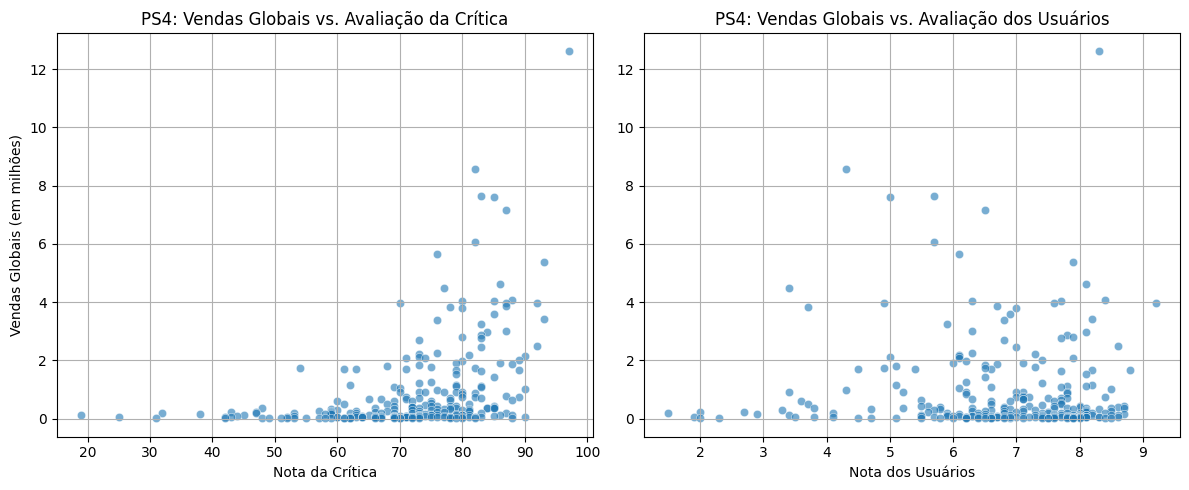

Correlação entre vendas e nota da crítica (PS4): 0.41
Correlação entre vendas e nota dos usuários (PS4): -0.03


In [14]:
# Filtrando apenas jogos de PS4 com notas válidas e no período de interesse
ps4_df = df[
    (df['platform'] == 'PS4') &
    (df['year_of_release'].between(2012, 2016)) &
    (~df['critic_score'].isna()) &
    (~df['user_score'].isna())
]

# Gráfico de dispersão: Vendas x Nota dos críticos
plt.figure(figsize=[12, 5])
plt.subplot(1, 2, 1)
sns.scatterplot(x='critic_score', y='total_sales', data=ps4_df, alpha=0.6)
plt.title('PS4: Vendas Globais vs. Avaliação da Crítica')
plt.xlabel('Nota da Crítica')
plt.ylabel('Vendas Globais (em milhões)')
plt.grid(True)

# Gráfico de dispersão: Vendas x Nota dos usuários
plt.subplot(1, 2, 2)
sns.scatterplot(x='user_score', y='total_sales', data=ps4_df, alpha=0.6)
plt.title('PS4: Vendas Globais vs. Avaliação dos Usuários')
plt.xlabel('Nota dos Usuários')
plt.ylabel('')
plt.grid(True)

plt.tight_layout()
plt.show()

# Correlação de Pearson
critic_corr = ps4_df['total_sales'].corr(ps4_df['critic_score'])
user_corr = ps4_df['total_sales'].corr(ps4_df['user_score'])

print(f'Correlação entre vendas e nota da crítica (PS4): {critic_corr:.2f}')
print(f'Correlação entre vendas e nota dos usuários (PS4): {user_corr:.2f}')

### Avaliações da Crítica e dos Usuários vs. Vendas (PS4)

Os gráficos de dispersão acima mostram a relação entre as avaliações dos jogos de PS4 (lançados entre 2012 e 2016) e suas vendas globais. Também foi calculado o coeficiente de correlação de Pearson para cada tipo de avaliação:

- **Correlação com nota da crítica**: `0.41`  
- **Correlação com nota dos usuários**: `-0.03`


#### Análise:

- Existe uma **correlação moderada positiva** entre as **notas da crítica** e as vendas. Isso indica que jogos bem avaliados por especialistas tendem a vender mais, embora haja exceções (outliers) com grande sucesso mesmo com avaliações medianas.

- Por outro lado, as **notas dos usuários apresentam correlação praticamente nula** com as vendas. Isso pode sugerir que:
  - O sucesso comercial pode ser impulsionado por marketing, franquias conhecidas ou expectativas pré-lançamento, e não necessariamente pela opinião popular após o lançamento.
  - Avaliações de usuários tendem a ser mais voláteis, influenciadas por polarizações, fandoms ou boicotes.


#### Conclusão:

Para prever o sucesso de vendas ou identificar jogos promissores, **a avaliação da crítica parece ser um indicador mais confiável** do que a nota atribuída pelos usuários.

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

- A correlação entre atributos de `score` e vendas foi calculada.
- As conclusões foram apresentadas. Bom trabalho com a apresentação dos resultados acima!
</div>

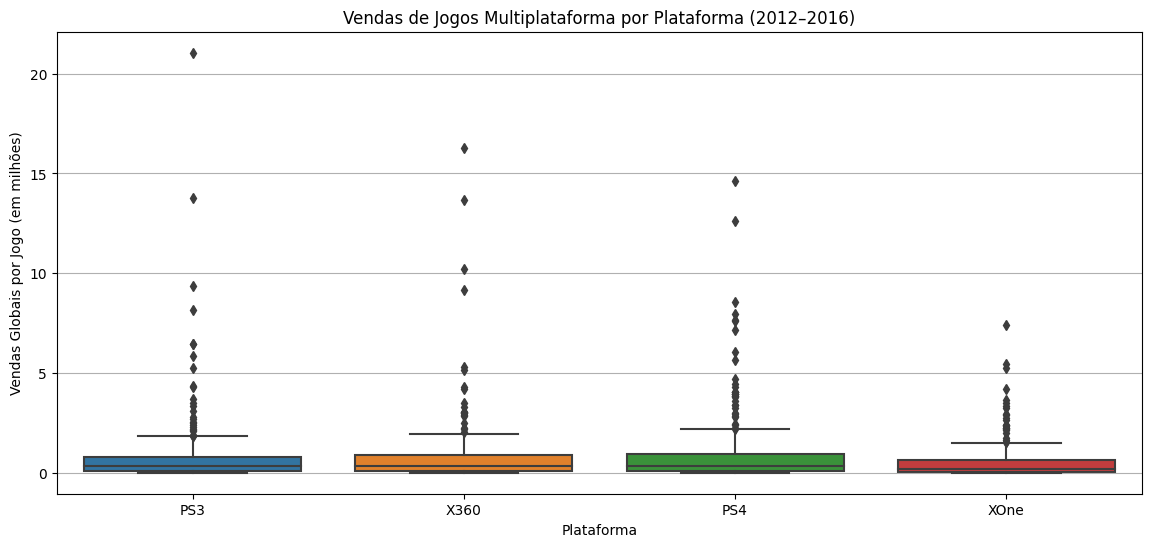

In [15]:
# Selecionar apenas jogos lançados entre 2012 e 2016 e nas principais plataformas
multi_df = df[
    (df['year_of_release'].between(2012, 2016)) &
    (df['platform'].isin(['PS4', 'XOne', 'PS3', 'X360']))
]

# Agrupar por nome e contar quantas plataformas diferentes têm o mesmo jogo
multi_platform_counts = multi_df.groupby('name')['platform'].nunique()
multi_platform_games = multi_platform_counts[multi_platform_counts > 1].index

# Filtrar apenas os jogos multiplataforma
multi_platform_df = multi_df[multi_df['name'].isin(multi_platform_games)]

# Criar boxplot para comparar a variação de vendas entre plataformas
plt.figure(figsize=[14, 6])
sns.boxplot(x='platform', y='total_sales', data=multi_platform_df)
plt.title('Vendas de Jogos Multiplataforma por Plataforma (2012–2016)')
plt.xlabel('Plataforma')
plt.ylabel('Vendas Globais por Jogo (em milhões)')
plt.grid(axis='y')
plt.show()

## Comparação de Vendas dos Mesmos Jogos em Diferentes Plataformas

O gráfico acima mostra a distribuição das vendas globais por jogo para títulos **multiplataforma** — ou seja, lançados em duas ou mais das seguintes plataformas: **PS3, X360, PS4 e XOne**, entre os anos de **2012 e 2016**.

### Principais observações:

- A **distribuição geral é bastante semelhante** entre as plataformas, com muitos jogos vendendo menos de 1 milhão de unidades e alguns *outliers* dominando em vendas.
- **PS4** apresenta uma **leve vantagem na mediana** e maior presença entre os *outliers* — indicando que alguns dos maiores sucessos comerciais multiplataforma no período ocorreram nessa plataforma.
- **PS3 e X360**, embora ainda relevantes, mostram uma **leve tendência de queda** em relação às plataformas mais novas (PS4 e XOne), com menor dispersão nas faixas superiores.
- **Xbox One (XOne)** tem distribuição comparável à do X360, mas com menor concentração de *outliers*, sugerindo que a transição para a nova geração ainda estava em andamento no período observado.

### Conclusão:

Mesmo quando analisamos os **mesmos jogos**, a **plataforma de lançamento influencia significativamente o volume de vendas**. O **PS4 se destaca** como a plataforma mais lucrativa para títulos multiplataforma no período recente, o que reforça seu papel como principal candidata a campanhas publicitárias para 2017.

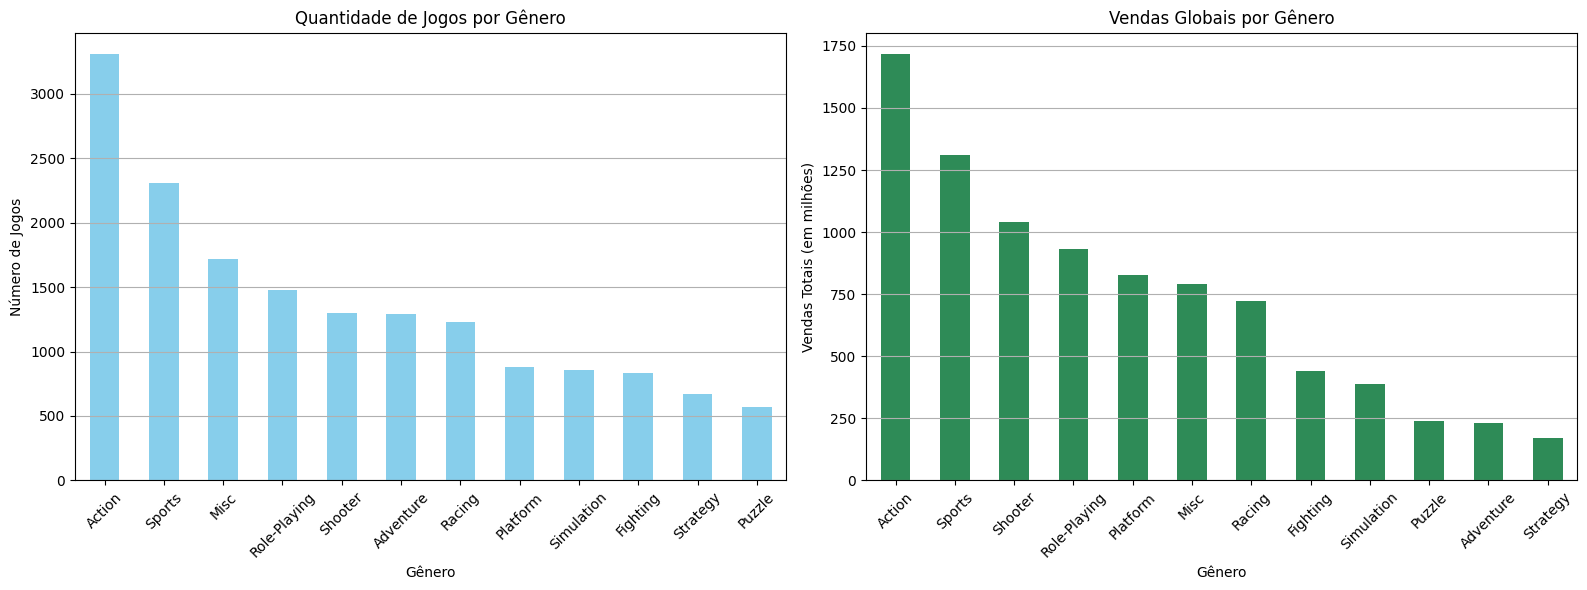

In [16]:
# Agrupando o número de jogos por gênero
genre_counts = df['genre'].value_counts().sort_values(ascending=False)

# Agrupando as vendas totais por gênero
genre_sales = df.groupby('genre')['total_sales'].sum().sort_values(ascending=False)

# Plotando lado a lado: quantidade de jogos e vendas por gênero
plt.figure(figsize=[16, 6])

# Gráfico 1 – Número de jogos por gênero
plt.subplot(1, 2, 1)
genre_counts.plot(kind='bar', color='skyblue')
plt.title('Quantidade de Jogos por Gênero')
plt.xlabel('Gênero')
plt.ylabel('Número de Jogos')
plt.xticks(rotation=45)
plt.grid(axis='y')

# Gráfico 2 – Vendas totais por gênero
plt.subplot(1, 2, 2)
genre_sales.plot(kind='bar', color='seagreen')
plt.title('Vendas Globais por Gênero')
plt.xlabel('Gênero')
plt.ylabel('Vendas Totais (em milhões)')
plt.xticks(rotation=45)
plt.grid(axis='y')

plt.tight_layout()
plt.show()

### Distribuição Geral de Jogos por Gênero

Os gráficos acima comparam a **quantidade de lançamentos** e o **volume total de vendas** globais por gênero.

#### Principais observações:

- O gênero **Action** lidera em ambos os gráficos, com mais de 3.000 jogos lançados e também a maior soma de vendas — o que evidencia sua **popularidade massiva e comercialmente bem-sucedida**.
- **Sports** também apresenta um ótimo desempenho, sendo o **segundo gênero mais lançado e mais vendido**, puxado por franquias como FIFA e NBA.
- **Shooter** aparece apenas em 5º lugar em número de títulos, mas figura entre os 3 primeiros em vendas — indicando um gênero **altamente lucrativo mesmo com menor volume**, impulsionado por títulos como Call of Duty e Battlefield.
- Gêneros como **Platform** e **RPG** mantêm um equilíbrio razoável entre quantidade e rentabilidade.
- **Adventure, Puzzle e Strategy**, embora tenham muitos lançamentos, geram **baixas vendas totais**, o que sugere que são nichos menos rentáveis para o público geral.

#### Conclusão:

Gêneros como **Action, Sports e Shooter** não só dominam em número de lançamentos, como também concentram a maior parte das vendas globais. Isso indica que, para 2017, esses gêneros devem ser considerados prioritários em campanhas publicitárias e investimentos, especialmente em plataformas em ascensão como PS4 e XOne.

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

- As análises de vendas e receita por gênero foi conduzida
- A conclusão foi apresentada
</div>

## Etapa 4 – Criação de Perfis Regionais de Usuários

Nesta etapa, o objetivo é identificar as preferências de consumo de jogos nas três principais regiões do mercado global:

- **América do Norte (NA)**
- **Europa (EU)**
- **Japão (JP)**

A análise será dividida em três frentes para cada região:

1. **As cinco plataformas mais populares**: serão identificadas as plataformas com maiores volumes de vendas e suas participações entre as regiões serão comparadas.
2. **Os cinco gêneros mais vendidos**: será examinado como os gostos variam culturalmente de uma região para outra em termos de estilo de jogo.
3. **O impacto da classificação ESRB nas vendas**: será verificado se a classificação etária influencia o desempenho comercial em cada região.

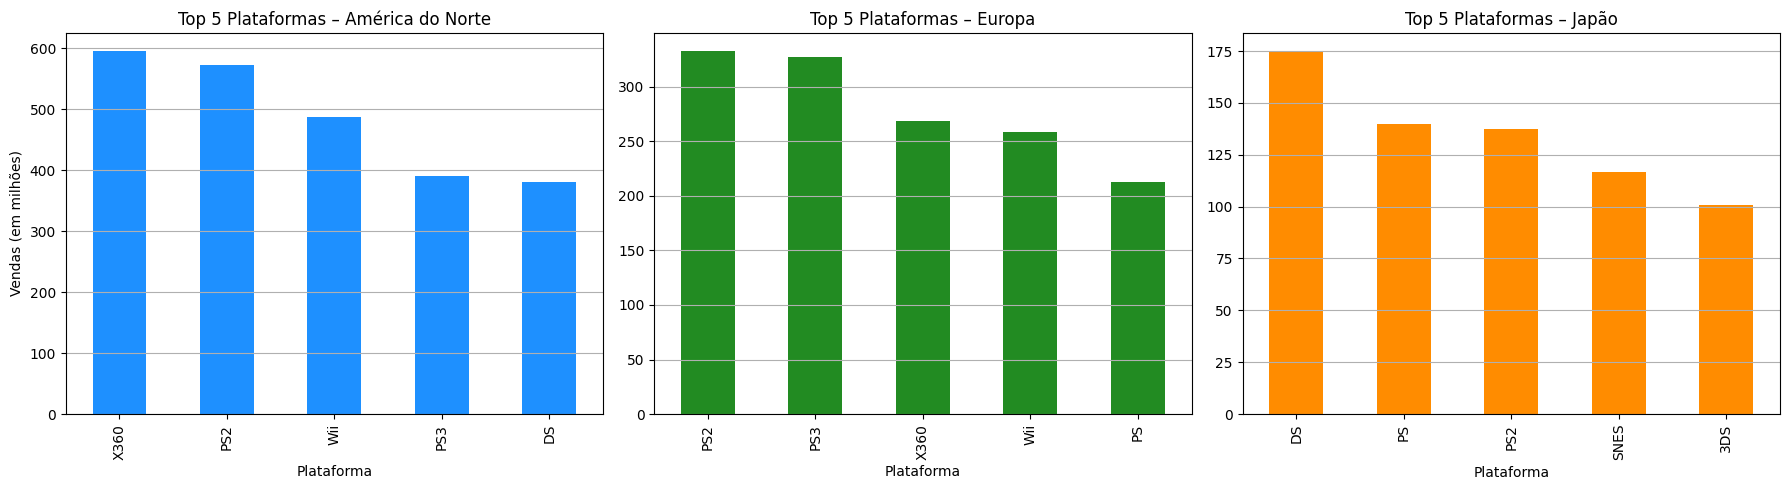

platform
PS4     1.796289
PS3     1.759033
X360    1.710437
XOne    1.011217
Name: total_sales, dtype: float64


In [17]:
# Agrupar vendas por plataforma e região
na_platforms = df.groupby('platform')['na_sales'].sum().sort_values(ascending=False).head(5)
eu_platforms = df.groupby('platform')['eu_sales'].sum().sort_values(ascending=False).head(5)
jp_platforms = df.groupby('platform')['jp_sales'].sum().sort_values(ascending=False).head(5)

# Plotando os três gráficos lado a lado
plt.figure(figsize=[18, 5])

plt.subplot(1, 3, 1)
na_platforms.plot(kind='bar', color='dodgerblue')
plt.title('Top 5 Plataformas – América do Norte')
plt.xlabel('Plataforma')
plt.ylabel('Vendas (em milhões)')
plt.grid(axis='y')

plt.subplot(1, 3, 2)
eu_platforms.plot(kind='bar', color='forestgreen')
plt.title('Top 5 Plataformas – Europa')
plt.xlabel('Plataforma')
plt.ylabel('')
plt.grid(axis='y')

plt.subplot(1, 3, 3)
jp_platforms.plot(kind='bar', color='darkorange')
plt.title('Top 5 Plataformas – Japão')
plt.xlabel('Plataforma')
plt.ylabel('')
plt.grid(axis='y')

plt.tight_layout()
plt.show()

# Calcular o desvio padrão das vendas por plataforma (jogos multiplataforma)
std_by_platform = multi_platform_df.groupby('platform')['total_sales'].std().sort_values(ascending=False)
print(std_by_platform)

### Top 5 Plataformas por Região

Os gráficos acima mostram as cinco plataformas com maior volume de vendas em três regiões distintas: América do Norte (NA), Europa (EU) e Japão (JP).

Além disso, o cálculo do **desvio padrão das vendas por jogo em cada plataforma** revela o nível de variação no desempenho dos títulos, permitindo identificar quais plataformas concentram maiores sucessos e quais apresentam desempenho mais equilibrado:

- **PS4**: 1.80  
- **PS3**: 1.76  
- **X360**: 1.71  
- **XOne**: 1.01  

**Interpretação**: PS4 lidera com a **maior variação nas vendas**, sugerindo presença de títulos extremamente bem-sucedidos. Já o XOne apresenta **menor desvio padrão**, indicando um comportamento mais estável entre os jogos lançados.

---

#### América do Norte (NA):
1. **X360**
2. **PS2**
3. **Wii**
4. **PS3**
5. **DS**

A América do Norte mostra forte preferência por consoles domésticos, especialmente da **Microsoft (X360)** e **Sony (PS2/PS3)**. O sucesso do **Wii** também é notável, com forte adesão ao público casual. Portáteis como **DS** aparecem com boa performance, mas atrás dos consoles de mesa.

#### Europa (EU):
1. **PS2**
2. **PS3**
3. **X360**
4. **Wii**
5. **PS**

A Europa tem uma **forte dominância da Sony**, com quatro consoles da marca no top 5. A **PS2** lidera com folga, mostrando sua longevidade no continente. A **X360** ainda ocupa uma posição relevante, mas atrás do PS3.

#### Japão (JP):
1. **DS**
2. **PS**
3. **PS2**
4. **SNES**
5. **3DS**

O Japão exibe um perfil muito diferente, com **grande preferência por consoles portáteis** (DS, 3DS) e **plataformas mais antigas** como SNES e PS1. O destaque para o **Nintendo DS** reflete a cultura japonesa de consumo móvel e o sucesso de franquias locais. Microsoft não aparece entre os mais vendidos.

---

#### Conclusão:

- **América do Norte** é um mercado mais receptivo a consoles da **Microsoft**, com preferência por jogos competitivos e ação.
- **Europa** tende a ser dominada por **plataformas da Sony**, especialmente PlayStation, indicando fidelidade à marca e sucesso de RPGs e esportes.
- **Japão** favorece **portáteis e plataformas clássicas da Nintendo e Sony**, com forte apego a títulos locais e experiências solo.

Essas diferenças devem ser consideradas em qualquer **estratégia de marketing segmentada por região**, respeitando os hábitos culturais de consumo e levando em conta também a **variabilidade nas vendas entre os jogos** observada por plataforma.

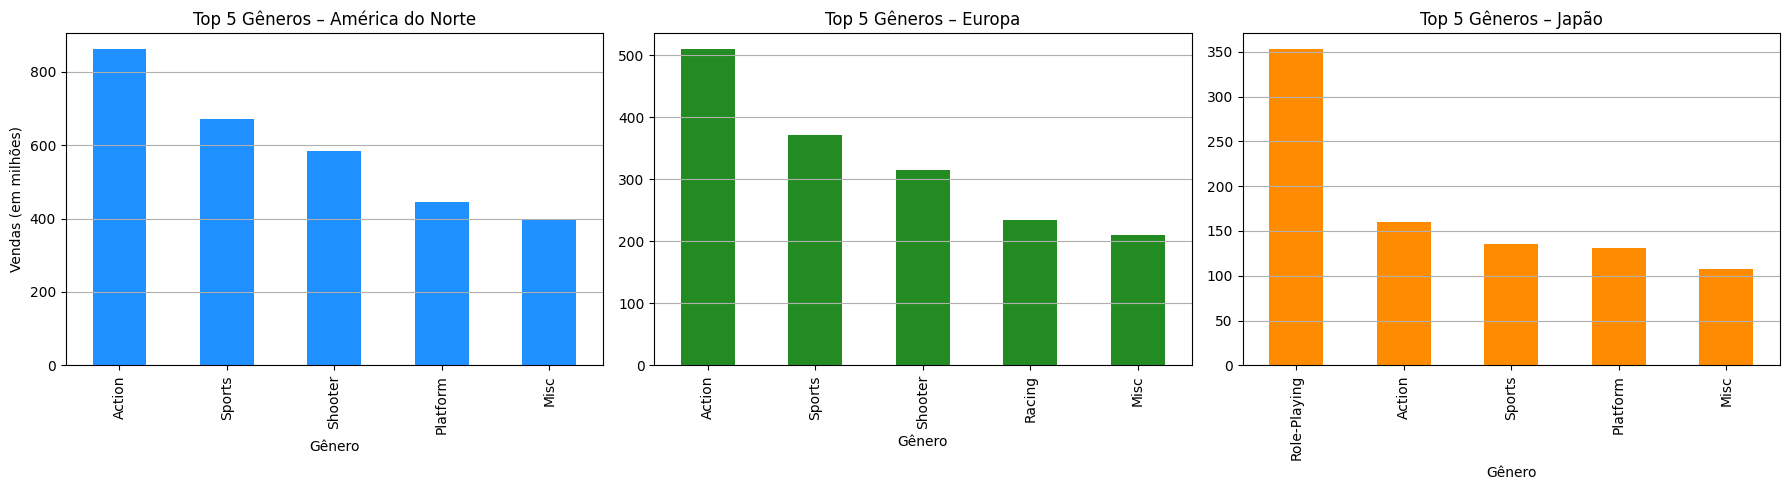

Desvio Padrão - América do Norte:
genre
Platform    1.504557
Shooter     1.209710
Puzzle      1.069026
Sports      1.043081
Racing      0.746353
Name: na_sales, dtype: float64 

Desvio Padrão - Europa:
genre
Sports        0.784716
Platform      0.586754
Racing        0.582491
Shooter       0.553901
Simulation    0.515817
Name: eu_sales, dtype: float64 

Desvio Padrão - Japão:
genre
Role-Playing    0.650987
Platform        0.527540
Puzzle          0.368252
Simulation      0.305709
Racing          0.269305
Name: jp_sales, dtype: float64


In [18]:
# Agrupando as vendas totais por gênero e região
na_genres = df.groupby('genre')['na_sales'].sum().sort_values(ascending=False).head(5)
eu_genres = df.groupby('genre')['eu_sales'].sum().sort_values(ascending=False).head(5)
jp_genres = df.groupby('genre')['jp_sales'].sum().sort_values(ascending=False).head(5)

# Plotando os três gráficos lado a lado
plt.figure(figsize=[18, 5])

plt.subplot(1, 3, 1)
na_genres.plot(kind='bar', color='dodgerblue')
plt.title('Top 5 Gêneros – América do Norte')
plt.xlabel('Gênero')
plt.ylabel('Vendas (em milhões)')
plt.grid(axis='y')

plt.subplot(1, 3, 2)
eu_genres.plot(kind='bar', color='forestgreen')
plt.title('Top 5 Gêneros – Europa')
plt.xlabel('Gênero')
plt.ylabel('')
plt.grid(axis='y')

plt.subplot(1, 3, 3)
jp_genres.plot(kind='bar', color='darkorange')
plt.title('Top 5 Gêneros – Japão')
plt.xlabel('Gênero')
plt.ylabel('')
plt.grid(axis='y')

plt.tight_layout()
plt.show()

# Calculando o desvio padrão por gênero e região
na_std = df.groupby('genre')['na_sales'].std().sort_values(ascending=False)
eu_std = df.groupby('genre')['eu_sales'].std().sort_values(ascending=False)
jp_std = df.groupby('genre')['jp_sales'].std().sort_values(ascending=False)

# Exibindo os 5 gêneros com maior variação por região
print("Desvio Padrão - América do Norte:")
print(na_std.head(5), '\n')

print("Desvio Padrão - Europa:")
print(eu_std.head(5), '\n')

print("Desvio Padrão - Japão:")
print(jp_std.head(5))

### Gêneros Mais Vendidos por Região

Os gráficos acima revelam as preferências regionais em termos de **gêneros de jogos**, baseadas no volume total de vendas.

#### América do Norte (NA):
1. **Action**
2. **Sports**
3. **Shooter**
4. **Platform**
5. **Misc**

A América do Norte mostra um claro favoritismo por jogos de **ação e tiro**, com os gêneros **Shooter** e **Action** dominando as vendas. **Esportes** também têm uma forte presença, impulsionados por franquias como *Madden* e *NBA*. Gêneros como **Platform** (ex: *Mario*) ainda mantêm uma base fiel.

**Desvio padrão nas vendas por gênero (NA):**
- Platform: 1.50  
- Shooter: 1.21  
- Puzzle: 1.07  
- Sports: 1.04  
- Racing: 0.75  

> Os gêneros **Platform** e **Shooter** possuem maior variação nas vendas, indicando presença de grandes sucessos individuais que elevam a média do grupo.

---

#### Europa (EU):
1. **Action**
2. **Sports**
3. **Shooter**
4. **Racing**
5. **Misc**

A Europa tem perfil semelhante ao norte-americano, com **Action, Sports e Shooter** como gêneros dominantes. No entanto, **Racing** aparece em destaque, possivelmente pela popularidade de títulos como *Gran Turismo* e *FIFA* com modos de corrida.

**Desvio padrão nas vendas por gênero (EU):**
- Sports: 0.78  
- Platform: 0.59  
- Racing: 0.58  
- Shooter: 0.55  
- Simulation: 0.52  

> O maior desvio padrão em **Sports** indica que alguns títulos superam amplamente os demais, enquanto gêneros como **Simulation** são mais consistentes em desempenho.

---

#### Japão (JP):
1. **Role-Playing (RPG)**
2. **Action**
3. **Sports**
4. **Platform**
5. **Misc**

O Japão apresenta uma diferença marcante: **Role-Playing** lidera com folga, refletindo a tradição de franquias locais como *Pokémon*, *Final Fantasy* e *Dragon Quest*. Ação e esportes aparecem, mas com menor destaque. **Platform** continua relevante, especialmente entre os títulos da Nintendo.

**Desvio padrão nas vendas por gênero (JP):**
- Role-Playing: 0.65  
- Platform: 0.53  
- Puzzle: 0.37  
- Simulation: 0.31  
- Racing: 0.27  

> O gênero **RPG**, apesar de liderar, também apresenta maior variação de desempenho, o que pode indicar uma concentração de vendas em poucas franquias.

---

#### Conclusão:

- **América do Norte** e **Europa** compartilham preferência por **ação, esportes e tiro**, embora a Europa também valorize jogos de corrida.
- **Japão** possui gostos únicos, com destaque para **RPGs** e **plataformas**, refletindo uma tradição de jogos solo e franquias locais.
- Gêneros como **Platform** e **Shooter** apresentam **alta variabilidade**, sugerindo maior risco ou maior potencial de sucesso.
- Estratégias de marketing e desenvolvimento de jogos devem ser **personalizadas por região**, levando em consideração a **volatilidade nas vendas** e as **preferências culturais**.

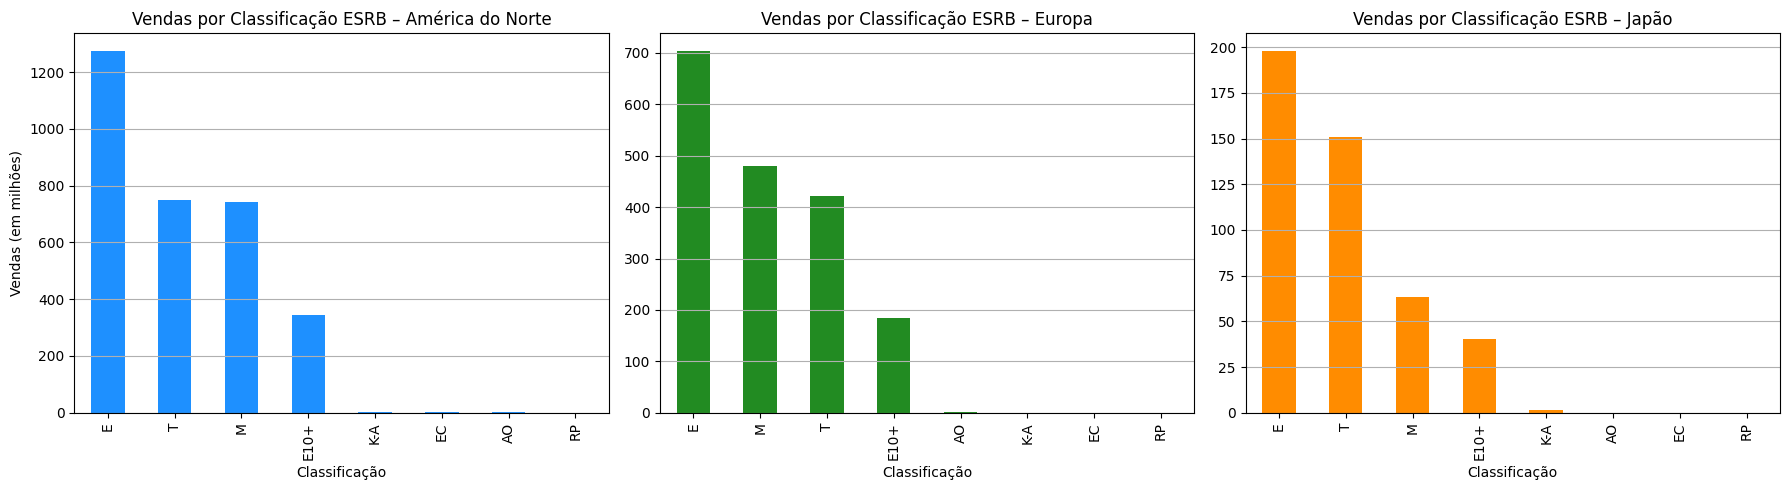

Desvio Padrão - América do Norte:
rating
K-A     1.259577
M       1.039992
E       1.018775
T       0.456975
E10+    0.436827
EC      0.142371
AO           NaN
RP           NaN
Name: na_sales, dtype: float64

Desvio Padrão - Europa:
rating
E       0.758559
M       0.653637
T       0.334333
E10+    0.269245
K-A     0.075498
EC      0.031595
AO           NaN
RP           NaN
Name: eu_sales, dtype: float64

Desvio Padrão - Japão:
rating
K-A     0.842931
E       0.305504
T       0.222534
E10+    0.167071
M       0.127521
EC      0.000000
AO           NaN
RP           NaN
Name: jp_sales, dtype: float64


In [19]:
# Filtrando apenas linhas com classificação ESRB válida
esrb_df = df[~df['rating'].isna()]

# Agrupando vendas por classificação ESRB para cada região
na_esrb = esrb_df.groupby('rating')['na_sales'].sum().sort_values(ascending=False)
eu_esrb = esrb_df.groupby('rating')['eu_sales'].sum().sort_values(ascending=False)
jp_esrb = esrb_df.groupby('rating')['jp_sales'].sum().sort_values(ascending=False)

# Gráficos lado a lado
plt.figure(figsize=[18, 5])

plt.subplot(1, 3, 1)
na_esrb.plot(kind='bar', color='dodgerblue')
plt.title('Vendas por Classificação ESRB – América do Norte')
plt.xlabel('Classificação')
plt.ylabel('Vendas (em milhões)')
plt.grid(axis='y')

plt.subplot(1, 3, 2)
eu_esrb.plot(kind='bar', color='forestgreen')
plt.title('Vendas por Classificação ESRB – Europa')
plt.xlabel('Classificação')
plt.ylabel('')
plt.grid(axis='y')

plt.subplot(1, 3, 3)
jp_esrb.plot(kind='bar', color='darkorange')
plt.title('Vendas por Classificação ESRB – Japão')
plt.xlabel('Classificação')
plt.ylabel('')
plt.grid(axis='y')

plt.tight_layout()
plt.show()

# Calculando o desvio padrão das vendas por classificação ESRB em cada região
na_std = esrb_df.groupby('rating')['na_sales'].std().sort_values(ascending=False)
eu_std = esrb_df.groupby('rating')['eu_sales'].std().sort_values(ascending=False)
jp_std = esrb_df.groupby('rating')['jp_sales'].std().sort_values(ascending=False)

# Exibindo os resultados
print("Desvio Padrão - América do Norte:")
print(na_std)
print("\nDesvio Padrão - Europa:")
print(eu_std)
print("\nDesvio Padrão - Japão:")
print(jp_std)

### Impacto da Classificação ESRB nas Vendas por Região

Os gráficos acima mostram o volume total de vendas por **classificação etária ESRB** nas três principais regiões: América do Norte, Europa e Japão.

#### América do Norte (NA):
- A classificação **E (Everyone)** lidera com ampla vantagem, superando 1200 milhões de unidades.
- **T (Teen)** e **M (Mature)** também possuem um volume elevado, indicando bom desempenho de jogos voltados ao público jovem e adulto.
- Outras classificações, como **E10+**, possuem vendas mais modestas, enquanto **AO (Adults Only)**, **EC (Early Childhood)** e **RP (Rating Pending)** são praticamente insignificantes.

##### Desvio padrão – América do Norte:
| Classificação | Desvio Padrão |
|---------------|----------------|
| K-A           | 1.259577       |
| M             | 1.039992       |
| E             | 1.018775       |
| T             | 0.456975       |
| E10+          | 0.436827       |
| EC            | 0.142371       |

> O maior desvio padrão foi observado em **K-A** e **M**, indicando grande variabilidade nas vendas dentro dessas classificações. Já **T** e **E10+** mostram padrões de venda mais consistentes.

---

#### Europa (EU):
- A distribuição é similar à da América do Norte, com **E** na liderança, seguida por **M** e **T**.
- A diferença aqui é que **Mature (M)** tem uma performance um pouco melhor relativa à América do Norte, o que pode indicar maior aceitação cultural de conteúdo adulto.
- Classificações como **E10+** têm menos impacto, e **AO/EC/RP** também são irrelevantes em volume.

##### Desvio padrão – Europa:
| Classificação | Desvio Padrão |
|---------------|----------------|
| E             | 0.758559       |
| M             | 0.653637       |
| T             | 0.334333       |
| E10+          | 0.269425       |
| K-A           | 0.075498       |
| EC            | 0.031595       |

> A classificação **E** apresenta maior variabilidade, sugerindo diferenças mais acentuadas entre os jogos voltados ao público geral. **EC** e **K-A** têm padrões bastante estáveis.

---

#### Japão (JP):
- Mais uma vez, **E** domina com folga, seguido de **T** e **M**, mas com volumes significativamente menores que nas outras regiões.
- O destaque fica para a **baixa expressividade das classificações M e E10+** no Japão, possivelmente pela existência de **sistemas de classificação locais** (como o CERO) mais usados no mercado japonês.
- Jogos com classificação **AO/EC/RP** praticamente não vendem.

##### Desvio padrão – Japão:
| Classificação | Desvio Padrão |
|---------------|----------------|
| K-A           | 0.842931       |
| E             | 0.305504       |
| T             | 0.222534       |
| E10+          | 0.167271       |
| M             | 0.127521       |
| EC            | 0.000000       |

> O Japão tem desvios padrão geralmente menores, mostrando que há **mais uniformidade nas vendas** entre os jogos de uma mesma classificação. Isso indica uma base de consumidores mais coesa em termos de preferência etária.

---

### Conclusão:

- A classificação **E (Everyone)** é consistentemente a mais rentável em todas as regiões, sendo o selo de jogos voltados para todos os públicos.
- Jogos **Teen (T)** e **Mature (M)** também são populares, mas a aceitação de conteúdo adulto varia um pouco culturalmente.
- Classificações extremas (**AO, EC, RP**) têm **baixíssimo impacto comercial** e devem ser evitadas em estratégias de marketing global.
- No Japão, a influência da **classificação ESRB é visivelmente menor**, sugerindo que outras entidades (como o CERO) são mais relevantes localmente.
- O **desvio padrão** reforça a ideia de que mercados como o norte-americano são mais diversos em termos de desempenho dentro de cada classificação, enquanto o japonês é mais coeso.

Esse entendimento é útil para alinhar campanhas regionais ao público-alvo certo, respeitando limites culturais e demográficos.

<div class="alert alert-block alert-warning">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

O estudo por região foi conduzido corretamente. Como sugestão, você poderia calcular outras estatísticas como desvio padrão, por exemplo.
</div>

## Etapa 5 – Teste de Hipóteses

Nesta etapa, serão realizados testes estatísticos para verificar se **há diferença significativa nas avaliações dos usuários** com base em duas comparações:

---

### Hipótese 1: Avaliações dos usuários no Xbox One e PC são iguais?

#### Formulação das hipóteses:

- **H₀ (Hipótese Nula):** As **médias** das avaliações dos usuários para jogos de Xbox One e PC são **iguais**.
  
  $H_0: \mu_{XboxOne} = \mu_{PC}$

- **H₁ (Hipótese Alternativa):** As médias das avaliações **são diferentes**.

  $H_1: \mu_{XboxOne} \ne \mu_{PC}$

#### Tipo de teste:
Teste **bicaudal para diferença entre médias** com amostras independentes.

---

### Hipótese 2: Avaliações de usuários para os gêneros Action e Sports são diferentes?

#### Formulação das hipóteses:

- **H₀ (Hipótese Nula):** As médias das avaliações dos usuários para os gêneros **Action** e **Sports** são **iguais**.

  $H_0: \mu_{Action} = \mu_{Sports}$

- **H₁ (Hipótese Alternativa):** As médias são **diferentes**.

  $H_1: \mu_{Action} \ne \mu_{Sports}$

#### Tipo de teste:
Também será um **teste bicaudal para diferença entre médias com amostras independentes**.

---

### Nível de Significância (α):

Será adotado um **nível de significância α = 0.05 (5%)**, que é o padrão em testes estatísticos e representa uma margem razoável de erro para inferências:

- **Interpretação:** Se o valor-p (p-value) obtido no teste for **menor que 0.05**, rejeitamos a hipótese nula.
- Esse nível representa **95% de confiança** nos resultados, equilibrando bem o risco de falso positivo (erro tipo I).

#### Como as Hipóteses Foram Formuladas:

As hipóteses nula (H₀) e alternativa (H₁) foram definidas com base nos princípios estatísticos de comparação entre médias, utilizando testes de hipótese para amostras independentes.

- **Hipótese Nula (H₀)**: Assume que **não há diferença significativa** entre as médias das duas populações analisadas. Ou seja, as diferenças observadas nas amostras são atribuídas ao acaso.
- **Hipótese Alternativa (H₁)**: Afirma que **existe uma diferença estatisticamente significativa** entre as médias das duas populações, sugerindo que os grupos se comportam de maneira diferente.

### Teste de Hipótese 1 – Diferença nas Avaliações dos Usuários: Xbox One vs PC

**Objetivo**: Verificar se existe uma diferença estatisticamente significativa nas classificações médias dadas por usuários para jogos nas plataformas **Xbox One** e **PC**.

**Formulação das Hipóteses**:
- **Hipótese Nula (H₀)**: As classificações médias dos usuários para jogos de Xbox One e PC são iguais.
- **Hipótese Alternativa (H₁)**: As classificações médias dos usuários para jogos de Xbox One e PC são diferentes.

**Nível de Significância (α)**: 0.05

In [20]:
# Converte a coluna 'user_score' para valores numéricos, tratando entradas inválidas como NaN
df['user_score'] = pd.to_numeric(df['user_score'], errors='coerce')

# Define o nível de significância (5%)
alpha = 0.05

# Filtra as notas dos usuários para os jogos lançados nas plataformas Xbox One e PC
xbox_scores = df[df['platform'] == 'XOne']['user_score'].dropna()
pc_scores = df[df['platform'] == 'PC']['user_score'].dropna()

# Aplica o teste t de Student para duas amostras independentes (sem assumir variâncias iguais)
tstat1, pval1 = stats.ttest_ind(xbox_scores, pc_scores, equal_var=False)

# Exibe os resultados do teste
print('Hipótese 1 - Xbox One vs PC')
print(f'Estatística t: {tstat1:.6f}')
print(f'Valor-p: {pval1:.6f}')

# Avalia o resultado com base no valor-p
if pval1 < alpha:
    print('Resultado: Rejeitamos a hipótese nula - as médias são diferentes.\n')
else:
    print('Resultado: Não rejeitamos a hipótese nula - não há diferença significativa.\n')

Hipótese 1 - Xbox One vs PC
Estatística t: -4.671114
Valor-p: 0.000005
Resultado: Rejeitamos a hipótese nula - as médias são diferentes.



**Resultado do Teste**:
- Estatística t = -4.671114
- Valor-p = 0.000005

Como o valor-p é menor que o nível de significância (p < 0.05), **rejeitamos a hipótese nula**.

**Conclusão**: Existe uma diferença estatisticamente significativa entre as avaliações médias dos usuários para jogos de Xbox One e PC.

<div class="alert alert-block alert-danger">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>
<s>
    
O `p-value` acima deu `0.000`, o que não é esperado. Dica: aumente o número de casas decimais dentro do método `print()` ou simplesmente remova o `.3f` da formatação do valor. Como o valor de `p` é muito pequeno para este teste, o resultado acima pode ter sido causado por precisão decimal.
</s>
</div>

### Teste de Hipótese 2 – Diferença nas Avaliações dos Usuários: Action vs Sports

**Objetivo**: Verificar se existe uma diferença estatisticamente significativa nas classificações médias dadas por usuários para jogos dos gêneros **Action** e **Sports**.

**Formulação das Hipóteses**:
- **Hipótese Nula (H₀)**: As classificações médias dos usuários para jogos dos gêneros Action e Sports são iguais.
- **Hipótese Alternativa (H₁)**: As classificações médias dos usuários para jogos dos gêneros Action e Sports são diferentes.

**Nível de Significância (α)**: 0.05

In [21]:
# Define o nível de significância (5%)
alpha = 0.05

# Filtra as notas dos usuários para os gêneros Action e Sports
action_scores = df[df['genre'] == 'Action']['user_score'].dropna()
sports_scores = df[df['genre'] == 'Sports']['user_score'].dropna()

# Aplica o teste t de Student para duas amostras independentes (sem assumir variâncias iguais)
tstat2, pval2 = stats.ttest_ind(action_scores, sports_scores, equal_var=False)

# Exibe os resultados do teste
print('Hipótese 2 - Action vs Sports')
print(f'Estatística t: {tstat2:.3f}')
print(f'Valor-p: {pval2:.3f}')

# Avalia o resultado com base no valor-p
if pval2 < alpha:
    print('Resultado: Rejeitamos a hipótese nula - as médias são diferentes.\n')
else:
    print('Resultado: Não rejeitamos a hipótese nula - não há diferença significativa.\n')

Hipótese 2 - Action vs Sports
Estatística t: 1.789
Valor-p: 0.074
Resultado: Não rejeitamos a hipótese nula - não há diferença significativa.



**Resultado do Teste**:
- Estatística t = 1.789
- Valor-p = 0.074

Como o valor-p é maior que o nível de significância (p > 0.05), **não rejeitamos a hipótese nula**.

**Conclusão**: Não há evidências estatísticas suficientes para afirmar que existe uma diferença significativa entre as classificações médias dos usuários para jogos dos gêneros Action e Sports. As médias podem ser consideradas estatisticamente semelhantes.

## Conclusão Geral do Projeto

O objetivo deste projeto foi analisar o mercado global de videogames até o ano de 2016, utilizando dados históricos de vendas, avaliações e características dos jogos, a fim de identificar padrões que pudessem apoiar decisões estratégicas de marketing para o ano de 2017.

Durante a análise, foi feita uma preparação dos dados, com tratamento de valores ausentes, padronização dos tipos de dados e criação de métricas relevantes, como o total de vendas globais por jogo. A etapa exploratória revelou alguns pontos relevantes:

- **Tendência histórica de lançamentos**: observou-se um pico de lançamentos entre 2008 e 2009, seguido por um declínio gradual. Para garantir a confiabilidade das análises, foi selecionado o período de 2012 a 2016 como a janela de análise mais adequada para prever 2017.

- **Plataformas mais lucrativas**: plataformas como **PS4**, **XOne** e **3DS** mostraram forte crescimento e relevância recente, com **PS4** se destacando como a mais promissora, tanto em volume quanto em estabilidade de vendas por jogo.

- **Gêneros mais populares**: os gêneros **Action**, **Sports** e **Shooter** se consolidaram como os mais rentáveis globalmente, e também apresentaram bom desempenho regional, especialmente na América do Norte e Europa.

- **Impacto das avaliações nas vendas**: a análise de correlação mostrou que **avaliações da crítica têm influência moderada** nas vendas, ao passo que as **avaliações dos usuários não demonstram relação significativa**, o que reforça o papel da crítica especializada como fator preditivo de sucesso comercial.

- **Variações regionais**: foi possível identificar perfis distintos de consumo:
  - **América do Norte**: preferência por jogos de ação e consoles da Microsoft e Sony.
  - **Europa**: dominada por plataformas PlayStation e gêneros similares aos da América do Norte.
  - **Japão**: forte presença de **RPGs**, consoles portáteis e títulos locais, com menor influência da classificação ESRB.

- **Classificação etária**: a classificação **E (Everyone)** se destacou como a mais lucrativa em todas as regiões, reforçando a força de jogos voltados para todos os públicos.

### Testes de Hipóteses

Os testes de hipóteses estatísticos permitiram validar ou refutar diferenças nas avaliações de usuários:

- **Hipótese 1 (Xbox One vs PC)**: Rejeitamos a hipótese nula, indicando que as médias de avaliação são significativamente diferentes entre as plataformas.
- **Hipótese 2 (Action vs Sports)**: Não rejeitamos a hipótese nula, o que indica que as médias de avaliação são estatisticamente semelhantes para os dois gêneros.

---

### Considerações Finais

Com base em todos os achados, pode-se concluir que o **PS4** surge como o principal foco estratégico para 2017, com os gêneros **Action** e **Sports** como líderes em vendas. Além disso, as **diferenças regionais devem ser cuidadosamente consideradas** em ações de marketing segmentadas.

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

Excelente trabalho com a organização do seu projeto e da conclusão final!
</div>